## 1. Imports

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score,average_precision_score,f1_score,
    precision_score,recall_score,precision_recall_curve,roc_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
print("done")

done


## 2. Load & Split

In [ ]:
df = pd.read_csv("../data/raw/creditcard.csv")
print(f"Shape: {df.shape}  Fraud rate: {df['Class'].mean()*100:.3f}%")
TARGET = "Class"
X = df.drop(columns=[TARGET]); y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Train: {X_train.shape}  Test: {X_test.shape}  Ratio: {ratio:.1f}")

Shape: (284807, 31)  Fraud rate: 0.173%
Train: (227845, 30)  Test: (56962, 30)  Ratio: 577.3


## 3. Outlier Removal (Data-Driven)

Remove fraud transactions with extreme values in 5+ V-features (>3 std from fraud mean). If a transaction is extreme across many PCA components, it's likely an artifact.

In [ ]:
v_cols_all = [c for c in X_train.columns if c.startswith("V")]
fraud = X_train.loc[y_train == 1, v_cols_all]
mu, sg = fraud.mean(), fraud.std()
extreme = (X_train[v_cols_all].sub(mu).abs() > 3 * sg).astype(int)
n_extreme = extreme.sum(axis=1)
rows_to_drop = n_extreme[n_extreme >= 5].index
X_train_clean = X_train.drop(rows_to_drop)
y_train_clean = y_train.drop(rows_to_drop)
v_cols_all = [c for c in X_train.columns if c.startswith("V")]
print(f"Fraud train: {y_train.sum()}  Dropped {len(rows_to_drop)} rows  Clean fraud: {y_train_clean.sum()}")

Fraud train: 394  Dropped 192 rows  Clean fraud: 383


## 4. Feature Engineering

In [ ]:
def add_features(X):
    X = X.copy()
    X["Amount_log"] = np.log1p(X["Amount"])
    hour = (X["Time"] // 3600) % 24
    X["Hour_sin"] = np.sin(2 * np.pi * hour / 24)
    X["Hour_cos"] = np.cos(2 * np.pi * hour / 24)
    return X

Xtr_clean = add_features(X_train_clean)
Xte = add_features(X_test)
Xtr_clean.drop(columns=["Time","Amount"],inplace=True)
Xte.drop(columns=["Time","Amount"],inplace=True)

Xtr_dirty = add_features(X_train)
Xtr_dirty.drop(columns=["Time","Amount"],inplace=True)

v_cols = [c for c in Xtr_clean.columns if c.startswith("V")]
eng_cols = ["Amount_log","Hour_sin","Hour_cos"]
SCALE_COLS = eng_cols[:]

print(f"V features: {len(v_cols)}  Engineered: {len(eng_cols)}  Total: {len(v_cols)+len(eng_cols)}")

V features: 28  Engineered: 3  Total: 31


## 5. Feature Sets & Evaluate Function

In [ ]:
feature_sets = {
    "A (V only)": v_cols,
    "B (+Amount,Hour)": v_cols + eng_cols,
}
feature_sets_dirty = {
    "C (clean+B)": v_cols + eng_cols,
    "D (dirty+B)": v_cols + eng_cols,
}

def evaluate(model, Xtr, ytr, Xte, yte, scale=False):
    if scale:
        sx = RobustScaler()
        cols = [c for c in SCALE_COLS if c in Xtr.columns]
        if cols:
            Xtr = Xtr.copy(); Xte = Xte.copy()
            Xtr[cols] = sx.fit_transform(Xtr[cols])
            Xte[cols] = sx.transform(Xte[cols])
    model.fit(Xtr, ytr)
    probs = model.predict_proba(Xte)[:,1]
    preds = (probs >= 0.5).astype(int)
    return {
        "PR_AUC": average_precision_score(yte, probs),
        "ROC_AUC": roc_auc_score(yte, probs),
        "F1": f1_score(yte, preds),
        "Precision": precision_score(yte, preds, zero_division=0),
        "Recall": recall_score(yte, preds, zero_division=0),
        "probs": probs,
    }

## 6. Run Experiments

In [ ]:
models = {
    "LogisticRegression": LogisticRegression(class_weight="balanced",max_iter=1000,random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200,max_depth=10,class_weight="balanced",random_state=42,n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth=6,scale_pos_weight=ratio,random_state=42,n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=200,learning_rate=0.1,max_depth=8,num_leaves=32,class_weight="balanced",random_state=42,n_jobs=-1,verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=200,learning_rate=0.1,depth=6,auto_class_weights="Balanced",random_state=42,verbose=0),
}

all_results = []

for set_name, cols in feature_sets.items():
    Xtr = Xtr_clean[cols]; Xte_ = Xte[cols]
    scale = set_name != "A (V only)"
    for model_name, model in models.items():
        score = evaluate(model, Xtr, y_train_clean, Xte_, y_test, scale=scale)
        all_results.append({"Set":set_name,"Model":model_name,**score})
        print(f"{set_name:20s} {model_name:20s} PR={score['PR_AUC']:.4f}")

for set_name, cols in feature_sets_dirty.items():
    Xtr = Xtr_dirty[cols]; Xte_ = Xte[cols]
    scale = True
    for model_name, model in models.items():
        score = evaluate(model, Xtr, y_train, Xte_, y_test, scale=scale)
        all_results.append({"Set":set_name,"Model":model_name,**score})
        print(f"{set_name:20s} {model_name:20s} PR={score['PR_AUC']:.4f}")

results_df = pd.DataFrame(all_results)
pivot_pr = results_df.pivot_table(index="Set",columns="Model",values="PR_AUC",aggfunc="first")
print("\nPR-AUC by Set x Model")
print(pivot_pr.round(4).to_string())

A (V only)           LogisticRegression   PR=0.6989
A (V only)           RandomForest         PR=0.8067
A (V only)           XGBoost              PR=0.8641
A (V only)           LightGBM             PR=0.8686
A (V only)           CatBoost             PR=0.8547
B (+Amount,Hour)     LogisticRegression   PR=0.6891
B (+Amount,Hour)     RandomForest         PR=0.8194
B (+Amount,Hour)     XGBoost              PR=0.8730
B (+Amount,Hour)     LightGBM             PR=0.8693
B (+Amount,Hour)     CatBoost             PR=0.8621
C (clean+B)          LogisticRegression   PR=0.7086
C (clean+B)          RandomForest         PR=0.8214
C (clean+B)          XGBoost              PR=0.8797
C (clean+B)          LightGBM             PR=0.8907
C (clean+B)          CatBoost             PR=0.8567
D (dirty+B)          LogisticRegression   PR=0.7086
D (dirty+B)          RandomForest         PR=0.8214
D (dirty+B)          XGBoost              PR=0.8797
D (dirty+B)          LightGBM             PR=0.8907
D (dirty+B) 

## 7. Results Analysis

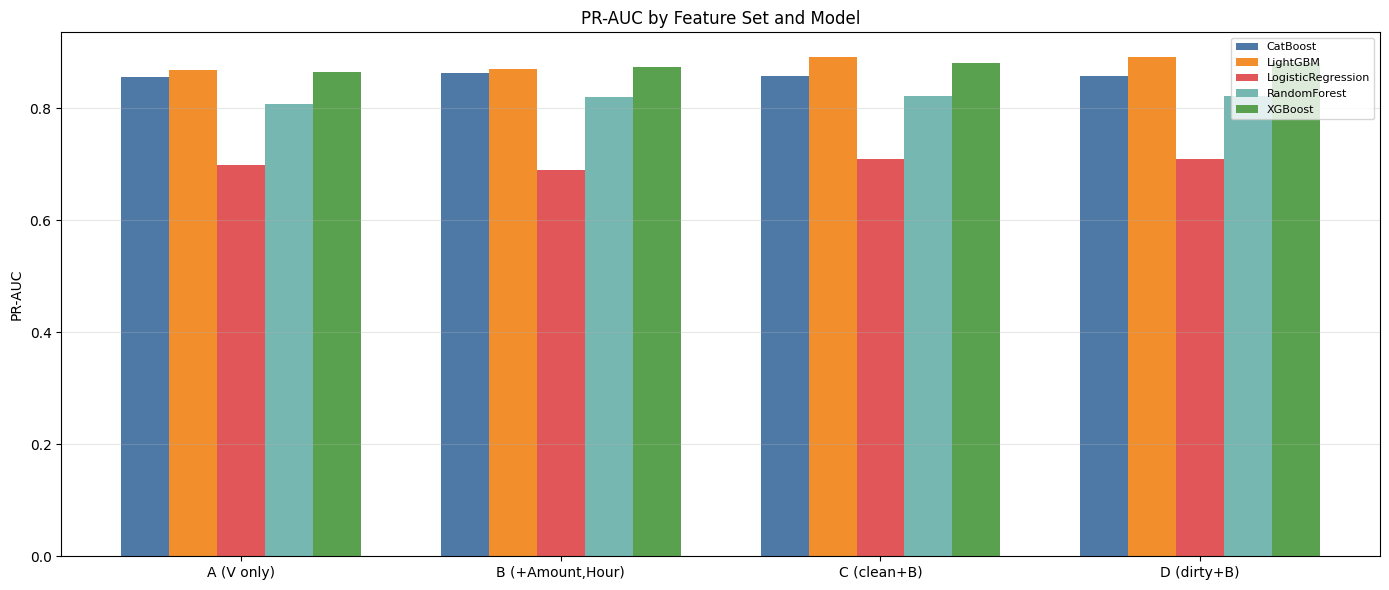

Best set per model:
  CatBoost             -> B (+Amount,Hour)     (0.8621)
  LightGBM             -> C (clean+B)          (0.8907)
  LogisticRegression   -> C (clean+B)          (0.7086)
  RandomForest         -> C (clean+B)          (0.8214)
  XGBoost              -> C (clean+B)          (0.8797)

Overall: C (clean+B) + LightGBM (PR-AUC=0.8907)


In [ ]:
fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(pivot_pr.index))
width = 0.15
colors = ["#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f"]
for i, model in enumerate(pivot_pr.columns):
    vals = pivot_pr[model].values
    ax.bar(x + i*width, vals, width, label=model, color=colors[i%len(colors)])
ax.set_xticks(x + width*2); ax.set_xticklabels(pivot_pr.index)
ax.set_ylabel("PR-AUC"); ax.set_title("PR-AUC by Feature Set and Model")
ax.legend(fontsize=8); ax.grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()

print("Best set per model:")
for m in pivot_pr.columns:
    bs = pivot_pr[m].idxmax(); bv = pivot_pr[m].max()
    print(f"  {m:20s} -> {bs:20s} ({bv:.4f})")

best_row = results_df.loc[results_df["PR_AUC"].idxmax()]
print(f"\nOverall: {best_row['Set']} + {best_row['Model']} (PR-AUC={best_row['PR_AUC']:.4f})")

## 8. Winning Combo Deep Dive

In [ ]:
winner_set = best_row["Set"]
winner_model_name = best_row["Model"]
print(f"Deep dive: {winner_set} with {winner_model_name}")

if "A (V only)" in winner_set:
    cols = feature_sets["A (V only)"]
elif "dirty" in winner_set:
    cols = feature_sets_dirty["D (dirty+B)"]
else:
    cols = feature_sets["B (+Amount,Hour)"]

if "clean" in winner_set or "C" in winner_set or "A" in winner_set or "B" in winner_set:
    Xtr_w = Xtr_clean[cols]; ytr_w = y_train_clean
else:
    Xtr_w = Xtr_dirty[cols]; ytr_w = y_train

Xte_w = Xte[cols]
scale = winner_set != "A (V only)"
score = evaluate(models[winner_model_name], Xtr_w, ytr_w, Xte_w, y_test, scale=scale)
probs = score["probs"]

from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, (probs >= 0.5).astype(int)).ravel()
print(f"PR-AUC={score['PR_AUC']:.4f} ROC-AUC={score['ROC_AUC']:.4f}")
print(f"F1={score['F1']:.4f} Prec={score['Precision']:.4f} Rec={score['Recall']:.4f}")
print(f"CM: TN={tn} FP={fp} FN={fn} TP={tp}")

Deep dive: C (clean+B) with LightGBM
PR-AUC=0.8693 ROC-AUC=0.9645
F1=0.8586 Prec=0.8817 Rec=0.8367
CM: TN=56853 FP=11 FN=16 TP=82


## 9. PR & ROC Curves

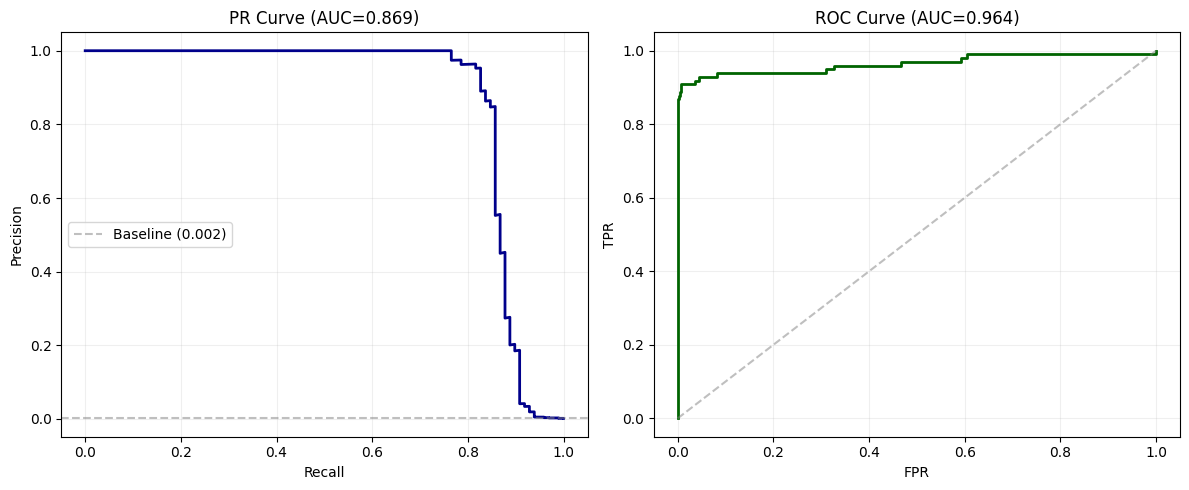

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

prec, rec, _ = precision_recall_curve(y_test, probs)
ax1.plot(rec, prec, color="darkblue", lw=2)
baseline = y_test.mean()
ax1.axhline(baseline, ls="--", color="gray", alpha=0.5, label=f"Baseline ({baseline:.3f})")
ax1.set_xlabel("Recall"); ax1.set_ylabel("Precision"); ax1.set_title(f"PR Curve (AUC={score['PR_AUC']:.3f})")
ax1.legend(); ax1.grid(alpha=0.2)

fpr, tpr, _ = roc_curve(y_test, probs)
ax2.plot(fpr, tpr, color="darkgreen", lw=2)
ax2.plot([0,1],[0,1], ls="--", color="gray", alpha=0.5)
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR"); ax2.set_title(f"ROC Curve (AUC={score['ROC_AUC']:.3f})")
ax2.grid(alpha=0.2)

plt.tight_layout(); plt.show()

## 10. Threshold Tuning

Best threshold: 0.85 -> F1=0.8757 Precision=0.9310 Recall=0.8265


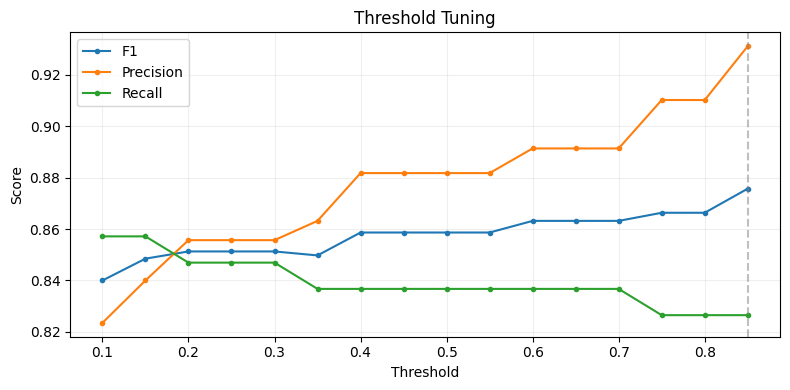

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1, best_th, best_metrics = 0, 0.5, {}
rows = []
for t in thresholds:
    p = (probs >= t).astype(int)
    f1 = f1_score(y_test, p)
    prec = precision_score(y_test, p, zero_division=0)
    rec = recall_score(y_test, p, zero_division=0)
    rows.append({"Threshold":t,"F1":f1,"Precision":prec,"Recall":rec})
    if f1 > best_f1:
        best_f1 = f1; best_th = t; best_metrics = {"F1":f1,"Precision":prec,"Recall":rec}
print(f"Best threshold: {best_th:.2f} -> F1={best_f1:.4f} Precision={best_metrics['Precision']:.4f} Recall={best_metrics['Recall']:.4f}")

thresh_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8,4))
for col in ["F1","Precision","Recall"]:
    ax.plot(thresh_df["Threshold"], thresh_df[col], label=col, marker=".")
ax.axvline(best_th, ls="--", color="gray", alpha=0.5)
ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_title("Threshold Tuning")
ax.legend(); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()

## 11. Feature Distribution Check

Quick sanity check: make sure Amount_log and Hour features separate fraud from non-fraud.

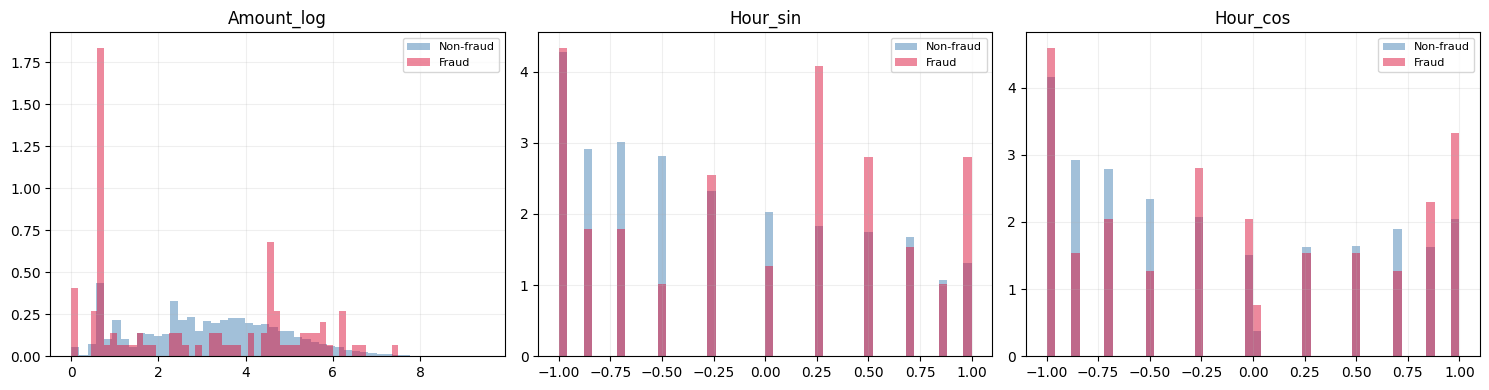

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
plot_df = Xte.copy()
plot_df["Class"] = y_test.values
titles = ["Amount_log","Hour_sin","Hour_cos"]
for ax, col in zip(axes, titles):
    for cls, color, label in zip([0,1], ["steelblue","crimson"], ["Non-fraud","Fraud"]):
        vals = plot_df.loc[plot_df["Class"]==cls, col]
        ax.hist(vals, bins=50, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col); ax.legend(fontsize=8); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

## 12. Manual Notes

**A (V only)** = baseline, 28 PCA components only.
**B (+Amount,Hour)** = V + Amount_log + Hour_sin/cos.
**C (clean+B)** = same as B but trained on outlier-cleaned data.
**D (dirty+B)** = same as B but trained on original dirty data.

Tree models (RF, XGB, LightGBM, CatBoost) handle feature scaling internally.
LogisticRegression gets `RobustScaler` on Amount_log/Hour_sin/Hour_cos.

**Interpretation:**
- If B > A, simple Amount+Hour features add value over V-only.
- If C > B, outlier removal helps (especially for logistic regression).
- If C ~ D, tree models are robust to outliers.
- If A > B, engineered features add noise (unlikely given EDA).